# 🌱 Crops Yield & Price Forecast | Manuel Lombardi
## 5. Modelado — Track B: Predicción de Rinde (Regresión)


### 5.1 Objetivo y criterios de éxito

Este notebook entrena y evalúa el modelo de predicción de rendimiento (qq/Ha) para los **6 cultivos** del proyecto (Girasol, Maíz, Maní, Soja 1ra, Soja 2da y Trigo total), migrado de 15 zonas PAS aproximadas por cajas rectangulares a **157 departamentos reales** con polígonos oficiales. Los criterios de éxito definidos en 01_business_understanding — MAE ≤ 5 qq/ha, R² ≥ 0.65, y una reducción de al menos 20% de MAE respecto al baseline de promedio histórico por zona — se retoman en la sección 5.8 para evaluar si el modelo los cumple.

Esta versión del modelo sigue usando `Zona` (zona PAS o zona Maní, ver notebook 03 sección 3.2.6) como proxy geográfico, igual que la versión de 15 zonas — **no** usa todavía `Departamento`/`Departamento_id` como feature. Esa es una decisión pendiente, no cerrada, que se plantea explícitamente en la sección 5.12 antes de guardar el modelo final.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import joblib
import json as json_lib
from pathlib import Path

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance


### 5.2 Carga y preparación de datos

#### 5.2.1 Carga de `dataset_modelo_rendimiento.csv`


In [2]:
df_modelo = pd.read_csv('../data/processed/dataset_modelo_rendimiento.csv')
print(df_modelo.shape)
print(df_modelo['Cultivo'].value_counts())
df_modelo.head()


(18537, 33)
Cultivo
soja 1ra       3851
maíz           3848
trigo total    3776
soja 2da       3555
girasol        3294
maní            213
Name: count, dtype: int64


,Cultivo,Anio_Inicio,Campaña,Departamento,Departamento_id,Sembrado(Ha),Cosechado(Ha),Producción(MTn),Perdido(Ha),Rinde(qq/Ha),...,temperatura_media_floracion,temperatura_media_llenado,ndvi_n_observaciones_floracion,ndvi_n_observaciones_llenado,ndvi_promedio_floracion,ndvi_promedio_llenado,oni_promedio_floracion,oni_promedio_llenado,oni_categoria_floracion,oni_categoria_llenado
0,girasol,2000,2000/2001,Azul,6049,16000,15500,25500,500,16.45,...,20.481522,23.032273,4,3,0.588929,0.634144,-0.77,-0.650000,Niña,Niña
1,girasol,2000,2000/2001,San Cayetano,6742,50500,49500,54450,1000,11.00,...,20.585652,21.618864,4,3,0.413184,0.538748,-0.77,-0.576667,Niña,Niña
2,girasol,2000,2000/2001,Trenque Lauquen,6826,21000,19000,42000,2000,22.11,...,23.746304,24.459318,4,3,0.562463,0.609815,-0.77,-0.576667,Niña,Niña
3,girasol,2000,2000/2001,San Pedro,6770,800,800,1760,0,22.00,...,22.863043,24.023636,4,3,0.599223,0.709321,-0.77,-0.650000,Niña,Niña
4,girasol,2000,2000/2001,Salliqueló,6721,11300,11225,18500,75,16.48,...,24.677826,24.535227,4,3,0.530454,0.610670,-0.77,-0.576667,Niña,Niña


#### 5.2.2 Selección de features

Se excluyen del set de features:

- **Identificadores** (`Cultivo`, `Zona`, `Campaña`, `Anio_Inicio`, `Departamento`, `Departamento_id`) — no son variables predictoras en sí. `Cultivo` y `Zona` vuelven a entrar más adelante como variables dummy (sección 5.4); `Departamento`/`Departamento_id` quedan afuera de esta versión del modelo (ver 5.12).
- **Columnas que fugan el target** (`Sembrado(Ha)`, `Perdido(Ha)`, `Cosechado(Ha)`, `Producción(MTn)`) — están relacionadas matemáticamente con `Rinde(qq/Ha)` por construcción, dejarlas sería casi fuga de datos. `Perdido(Ha)` en particular es ahora una columna derivada (`Sembrado - Cosechado`, ver notebook 03 sección 3.2.3) — sigue excluida por el mismo motivo (junto con `Sembrado(Ha)` determina `Cosechado(Ha)` de forma determinística).
- **Columnas de diagnóstico de NDVI** (`ndvi_n_observaciones_floracion`, `ndvi_n_observaciones_llenado`) — se confirma en 5.3.2 que no aportan señal real, quedan en el DataFrame para diagnóstico pero no como features.
- **Categóricas de ONI** (`oni_categoria_floracion`, `oni_categoria_llenado`) — versión discretizada de `oni_promedio_floracion`/`llenado` (ver notebook 03, 3.2.9), son texto (`'Niño'`/`'Niña'`/`'Neutral'`), no entran directo a un Random Forest de sklearn. Se usan puntualmente en 5.9.3 como dummies para comparar contra la versión continua; no forman parte del set de features por default.

In [3]:
columnas_no_features = [
    'Cultivo', 'Zona', 'Campaña', 'Departamento', 'Departamento_id',  # identificadores
    'Sembrado(Ha)', 'Perdido(Ha)', 'Cosechado(Ha)', 'Producción(MTn)',  # correlacionadas con el target por construcción (fuga)
    'Anio_Inicio',                          # identificador temporal
    'Rinde(qq/Ha)',                         # el target
    'ndvi_n_observaciones_floracion', 'ndvi_n_observaciones_llenado',  # diagnóstico, no features
    'oni_categoria_floracion', 'oni_categoria_llenado',  # texto, se usan como dummies puntualmente en 5.9.3
]

features = [c for c in df_modelo.columns if c not in columnas_no_features]
print(f"{len(features)} features base:")
features

18 features base:


['amplitud_termica_floracion',
 'amplitud_termica_llenado',
 'deficit_hidrico_extremo_floracion',
 'deficit_hidrico_extremo_llenado',
 'estres_termico_floracion',
 'estres_termico_llenado',
 'helada_agro_floracion',
 'helada_agro_llenado',
 'precipitacion_total_floracion',
 'precipitacion_total_llenado',
 'radiacion_solar_promedio_floracion',
 'radiacion_solar_promedio_llenado',
 'temperatura_media_floracion',
 'temperatura_media_llenado',
 'ndvi_promedio_floracion',
 'ndvi_promedio_llenado',
 'oni_promedio_floracion',
 'oni_promedio_llenado']

### 5.3 Análisis exploratorio de features

#### 5.3.1 Correlación entre features


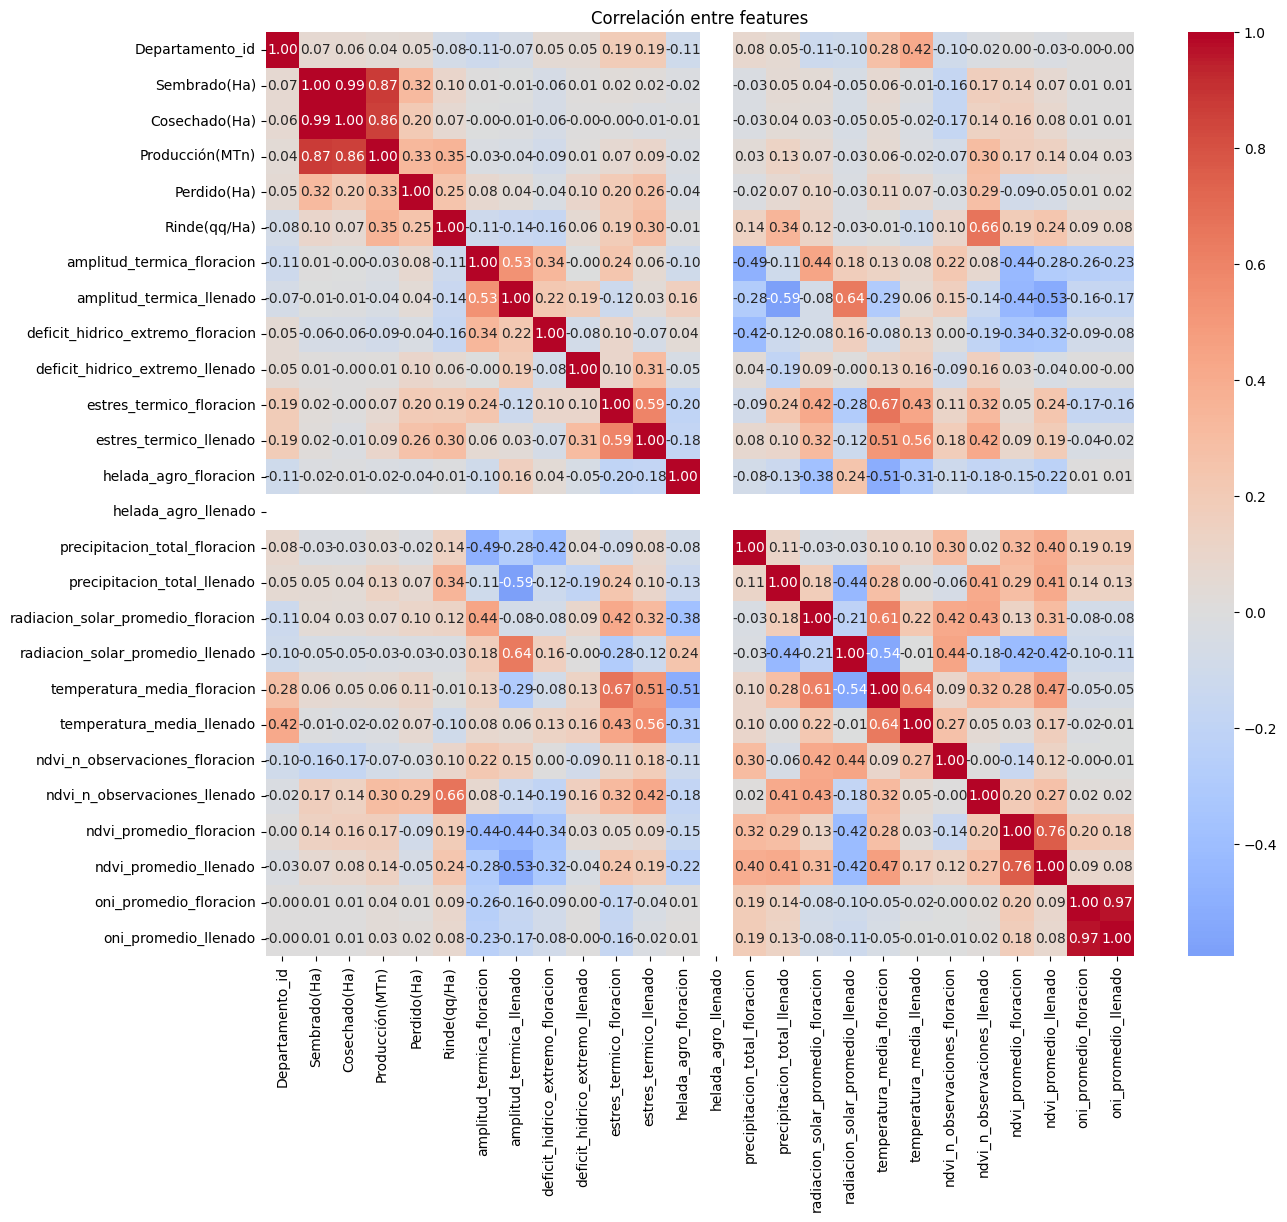

In [4]:
features_numericas = df_modelo.select_dtypes(include='number').drop(columns=['Anio_Inicio'])
corr = features_numericas.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre features')
plt.show()


El heatmap muestra `ndvi_n_observaciones_llenado` correlacionando **0.66** con `Rinde(qq/Ha)` — sospechoso, dado que es un conteo de compuestos MODIS dentro de la ventana, no una medida agronómica. `estres_termico_floracion/llenado` también llama la atención, con correlación agregada positiva y contraintuitiva (+0.19/+0.30 con el rendimiento — más estrés térmico, más rendimiento, no tiene sentido agronómico a primera vista). El chequeo de la siguiente sección investiga si estas correlaciones son señal real o un efecto de "qué cultivo es" disfrazado, igual que en la versión de 15 zonas.


#### 5.3.2 Chequeo de confusión por cultivo


In [5]:
def chequear_confusion_por_cultivo(df, columna):
    print(f'--- {columna} ---')
    print(df.groupby(['Cultivo', 'Zona'])[columna].std().describe())
    for cultivo in df['Cultivo'].unique():
        sub = df[df['Cultivo'] == cultivo]
        corr = sub[columna].corr(sub['Rinde(qq/Ha)'])
        print(f'  {cultivo}: {corr:.2f}')
    print()


In [6]:
for columna in ['ndvi_n_observaciones_floracion', 'ndvi_n_observaciones_llenado',
                'estres_termico_floracion', 'estres_termico_llenado']:
    chequear_confusion_por_cultivo(df_modelo, columna)


--- ndvi_n_observaciones_floracion ---
count    73.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: ndvi_n_observaciones_floracion, dtype: float64
  girasol: 0.27
  soja 2da: -0.08
  trigo total: nan
  maní: -0.06
  soja 1ra: 0.23
  maíz: 0.43

--- ndvi_n_observaciones_llenado ---
count    73.000000
mean      0.052915
std       0.142092
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.437726
Name: ndvi_n_observaciones_llenado, dtype: float64
  girasol: 0.27
  soja 2da: 0.17
  trigo total: nan
  maní: nan
  soja 1ra: 0.39
  maíz: 0.42

--- estres_termico_floracion ---
count    73.000000
mean      2.928946
std       2.126213
min       0.000000
25%       1.478722
50%       2.775938
75%       4.518336
max       7.171350
Name: estres_termico_floracion, dtype: float64
  girasol: -0.20
  soja 2da: -0.06
  trigo total: nan
  maní: nan
  soja 1ra: -0.23
  maíz: -0.35

--- estres_termico_llenado ---
c

C:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\manul\AppData\Local\Programs\Python\Python313\Lib\site-p

Separando por cultivo, la correlación de `ndvi_n_observaciones_llenado` con el rendimiento cae de 0.66 a un rango de -0.08 a 0.42 según el cultivo, y el desvío estándar dentro de cada grupo Cultivo×Zona es prácticamente 0 (`ndvi_n_observaciones_floracion` da std **exactamente 0** en las 73 combinaciones Cultivo×Zona que existen) — confirma que la correlación agregada es en gran medida un efecto de "qué cultivo/zona es" disfrazado: como las fechas de cada ventana fenológica son fijas por zona y cultivo, y los compuestos MODIS caen en fechas casi fijas año a año, la cantidad de observaciones que entran en la ventana es casi determinística, no una medida real de la campaña. **Se excluye del set de features** (ya está fuera desde 5.2.2).

`estres_termico_floracion/llenado` no se puede evaluar para **Trigo total** ni **Maní** (correlación indefinida, NaN): a Trigo se le calcula `helada_agro` en floración en vez de `estres_termico` (no le aplica el mismo umbral que a los cultivos de verano), y a Maní todavía no se le definió ningún umbral de estrés térmico (ver notebook 03, sección 3.2.7 — queda documentado como trabajo futuro, no se inventa un umbral). Para los 4 cultivos donde sí está definido, el signo es negativo y coherente agronómicamente en los cuatro: Girasol -0.20/-0.16, Soja 1ra -0.23/-0.21, Soja 2da -0.06/-0.10, Maíz -0.35/-0.24 (floración/llenado) — más estrés térmico, algo menos de rendimiento. **Se mantiene como feature.**


### 5.4 Estrategia de validación

#### 5.4.1 GroupKFold por Campaña

Un K-Fold aleatorio estándar mezclaría filas de una misma campaña entre train y test — el modelo terminaría entrenando "sabiendo" cómo fue el clima general de una campaña antes de que se le pida predecir sobre esa misma campaña, una fuga de información sutil que no refleja el escenario real (predecir sobre una campaña que todavía no ocurrió). `GroupKFold` con `Campaña` como grupo asegura que todas las filas de una misma campaña — todos los departamentos y cultivos — vayan enteras al mismo lado del split, nunca repartidas. Hay 25 campañas (2000/2001 a 2024/2025), las mismas 25 para los 6 cultivos — a diferencia de la versión de 15 zonas, ningún cultivo tiene menos historial que los demás.


In [7]:
dummies_cultivo = pd.get_dummies(df_modelo['Cultivo'], prefix='Cultivo')
df_modelo = pd.concat([df_modelo, dummies_cultivo], axis=1)
features = features + list(dummies_cultivo.columns)

y = df_modelo['Rinde(qq/Ha)']


`Cultivo` se suma como variable dummy porque los 6 cultivos tienen escalas de rendimiento muy distintas (Maíz 6.5-118.0 qq/ha vs. Girasol 4.5-40.4 qq/ha) — sin esto, el modelo no tiene forma de distinguir a qué cultivo pertenece cada fila y termina prediciendo valores fuera de escala.


#### 5.4.2 Funciones auxiliares


In [8]:
def entrenar_con_kfold(df, modelo_nombre, features, n_splits=5, usar_departamento_te=False, rf_params=None):

    if df is None:
        raise ValueError("El DataFrame no puede ser None")

    modelos_validos = ['baseline', 'random_forest', 'xgboost']
    if modelo_nombre not in modelos_validos:
        raise ValueError(f"modelo_nombre debe ser uno de {modelos_validos}")

    grupos = df['Campaña']

    gkf = GroupKFold(n_splits=n_splits)
    predicciones_oof = np.zeros(len(y))

    for idx_train, idx_test in gkf.split(df[features], y, groups=grupos):

        if usar_departamento_te and modelo_nombre != 'baseline':
            # target encoding de Departamento_id x Cultivo, calculado SOLO con el fold de train
            promedio_depto = df.iloc[idx_train].groupby(['Departamento_id', 'Cultivo'])['Rinde(qq/Ha)'].mean()
            fallback = y.iloc[idx_train].mean()
            claves = df[['Departamento_id', 'Cultivo']]
            encoding = claves.apply(
                lambda fila: promedio_depto.get((fila['Departamento_id'], fila['Cultivo']), fallback), axis=1
            )
            X = df[features].copy()
            X['depto_target_encoding'] = encoding
        else:
            X = df[features]

        if modelo_nombre == 'baseline':
            # promedio de Rinde por Zona+Cultivo, calculado SOLO con el fold de train
            promedio_zona = df.iloc[idx_train].groupby(['Zona', 'Cultivo'])['Rinde(qq/Ha)'].mean()
            claves_test = df.iloc[idx_test][['Zona', 'Cultivo']]
            pred = claves_test.apply(lambda fila: promedio_zona.get((fila['Zona'], fila['Cultivo']), y.iloc[idx_train].mean()), axis=1)
            predicciones_oof[idx_test] = pred.values

        elif modelo_nombre == 'random_forest':
            modelo = RandomForestRegressor(random_state=42, **(rf_params or {}))
            modelo.fit(X.iloc[idx_train], y.iloc[idx_train])
            predicciones_oof[idx_test] = modelo.predict(X.iloc[idx_test])

        elif modelo_nombre == 'xgboost':
            modelo = XGBRegressor(random_state=42)
            modelo.fit(X.iloc[idx_train], y.iloc[idx_train])
            predicciones_oof[idx_test] = modelo.predict(X.iloc[idx_test])

    return predicciones_oof


In [9]:
def calcular_metricas(y_real, y_pred, df, nombre_modelo):
    resultados = []

    mae_global = mean_absolute_error(y_real, y_pred)
    r2_global = r2_score(y_real, y_pred)
    resultados.append({'modelo': nombre_modelo, 'cultivo': 'GLOBAL', 'mae': mae_global, 'r2': r2_global})

    for cultivo in df['Cultivo'].unique():
        mask = df['Cultivo'] == cultivo
        mae_cultivo = mean_absolute_error(y_real[mask], y_pred[mask])
        r2_cultivo = r2_score(y_real[mask], y_pred[mask])
        resultados.append({'modelo': nombre_modelo, 'cultivo': cultivo, 'mae': mae_cultivo, 'r2': r2_cultivo})

    return pd.DataFrame(resultados)


### 5.5 Baseline — promedio histórico por zona

#### 5.5.1 Implementación


In [10]:
pred_baseline = entrenar_con_kfold(df_modelo, 'baseline', features)
metricas_baseline = calcular_metricas(y, pred_baseline, df_modelo, 'Baseline')


#### 5.5.2 Resultados por cultivo


In [11]:
print(metricas_baseline)


     modelo      cultivo        mae        r2
0  Baseline       GLOBAL   7.122134  0.763308
1  Baseline      girasol   3.681201  0.244825
2  Baseline     soja 2da   5.212597  0.174363
3  Baseline  trigo total   6.485318  0.506465
4  Baseline         maní   6.420697 -0.023795
5  Baseline     soja 1ra   5.800022  0.276565
6  Baseline         maíz  13.818684  0.323296


El R² GLOBAL (mezclando los 6 cultivos, 0.76) da bastante más alto que el R² por cultivo por separado (-0.02 a 0.51) — el baseline captura gran parte de esa diferencia solo por saber a qué cultivo pertenece cada fila, no por modelar variación real campaña a campaña. **La evaluación real es siempre por cultivo, nunca el GLOBAL agregado** — se retoma en la comparación final (5.8). Maní es el único cultivo con R² negativo en el baseline (-0.02): con sólo 213 filas (10 departamentos × hasta 25 campañas), el promedio histórico por Zona×Cultivo es un estimador más ruidoso ahí que en el resto.


### 5.6 Random Forest Regressor

#### 5.6.1 Entrenamiento y ajuste de hiperparámetros

Primer intento, con `Cultivo` como única variable dummy:


In [12]:
pred_rfr = entrenar_con_kfold(df_modelo, 'random_forest', features)

metricas_rfr = calcular_metricas(y, pred_rfr, df_modelo, 'Random Forest')


In [13]:
print(metricas_rfr)


          modelo      cultivo        mae        r2
0  Random Forest       GLOBAL   6.554726  0.801350
1  Random Forest      girasol   3.750983  0.189892
2  Random Forest     soja 2da   4.391496  0.414208
3  Random Forest  trigo total   6.974330  0.449768
4  Random Forest         maní   6.251850 -0.045943
5  Random Forest     soja 1ra   4.812727  0.493220
6  Random Forest         maíz  12.301699  0.457259


A diferencia de la versión de 15 zonas (donde Girasol quedaba con R² negativo sin `Zona` como feature), acá 5 de los 6 cultivos dan R² positivo sólo con `Cultivo` (Girasol 0.19, Soja 2da 0.41, Trigo 0.45, Soja 1ra 0.49, Maíz 0.46) — la migración a departamento parece haber hecho que el clima/NDVI/ONI por sí solos expliquen más varianza incluso sin la zona. La excepción es **Maní**, con R² levemente negativo (-0.05) — ya era el cultivo más débil de los seis (ver 5.3.2), con menos filas (213) y sin features de estrés térmico/helada definidas todavía (ver notebook 03, 3.2.7). Aun así, se agrega `Zona` como variable dummy para ver si corrige esto:

In [14]:
dummies_zona = pd.get_dummies(df_modelo['Zona'], prefix='Zona')
df_modelo = pd.concat([df_modelo, dummies_zona], axis=1)
features = features + list(dummies_zona.columns)

pred_rf_v2 = entrenar_con_kfold(df_modelo, 'random_forest', features)
metricas_rf_v2 = calcular_metricas(y, pred_rf_v2, df_modelo, 'Random Forest + Zona')


#### 5.6.2 Resultados (MAE, R² por fold)


In [15]:
print(metricas_rf_v2)


                 modelo      cultivo        mae        r2
0  Random Forest + Zona       GLOBAL   6.304127  0.816064
1  Random Forest + Zona      girasol   3.756519  0.194899
2  Random Forest + Zona     soja 2da   4.298602  0.438057
3  Random Forest + Zona  trigo total   6.447277  0.518099
4  Random Forest + Zona         maní   6.165638 -0.018528
5  Random Forest + Zona     soja 1ra   4.693091  0.510528
6  Random Forest + Zona         maíz  11.817257  0.497921


`Zona` mejora el R² en los 6 cultivos respecto a la versión sin ella (Girasol 0.190→0.195, Maní -0.046→-0.019, Maíz 0.457→0.498, Soja 1ra 0.493→0.511, Soja 2da 0.414→0.438, Trigo 0.450→0.518) — la mejora es consistente pero moderada, y no alcanza para devolver a **Maní** a R² positivo (queda en -0.019). Esta es la versión de Random Forest que se usa de acá en más (`pred_rf_v2` / `metricas_rf_v2`) para la comparación final y el análisis de errores.

### 5.7 XGBoost Regressor

#### 5.7.1 Entrenamiento y ajuste de hiperparámetros

Mismo `features` que la versión final de Random Forest (con `Cultivo` + `Zona`), para que la comparación en 5.8 sea pareja.


In [16]:
pred_xgb = entrenar_con_kfold(df_modelo, 'xgboost', features)
metricas_xgb = calcular_metricas(y, pred_xgb, df_modelo, 'XGBoost')


#### 5.7.2 Resultados (MAE, R² por fold)


In [17]:
print(metricas_xgb)


    modelo      cultivo        mae        r2
0  XGBoost       GLOBAL   6.804128  0.787620
1  XGBoost      girasol   4.120828  0.040692
2  XGBoost     soja 2da   4.870227  0.277107
3  XGBoost  trigo total   6.887973  0.458178
4  XGBoost         maní   6.671341 -0.221732
5  XGBoost     soja 1ra   5.270350  0.396570
6  XGBoost         maíz  12.347804  0.432842


XGBoost pierde contra Random Forest en los 6 cultivos, en las dos métricas, sin excepción — igual que en la versión de 15 zonas. Lo notable es que esto se repite con un dataset **~15 veces más grande** (18.537 filas contra 1.184 en la versión de 15 zonas), lo que debilita la explicación original de "dataset chico, XGBoost sobreajusta más que Random Forest": con 18.537 filas ya no es un dataset chico. Sin ajuste de hiperparámetros (ambos modelos se entrenan con los valores por default), es más probable que la brecha venga de que los defaults de Random Forest son más robustos out-of-the-box que los de XGBoost, que típicamente necesita tuning (learning rate, profundidad, regularización) para sacarle ventaja a Random Forest — no de un problema de tamaño de dataset. Queda como hipótesis a confirmar si se justifica invertir tiempo en tunear XGBoost más adelante.


### 5.8 Comparación de modelos y selección final

#### 5.8.1 Tabla comparativa: baseline vs. RF vs. XGBoost


In [18]:
tabla_comparativa = pd.concat([metricas_baseline, metricas_rf_v2, metricas_xgb], ignore_index=True)

tabla_mae = tabla_comparativa.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2 = tabla_comparativa.pivot(index='cultivo', columns='modelo', values='r2')

print('--- MAE (qq/ha) ---')
print(tabla_mae)
print()
print('--- R² ---')
print(tabla_r2)
print()

mejora_mae = 100 * (tabla_mae['Baseline'] - tabla_mae['Random Forest + Zona']) / tabla_mae['Baseline']
print('--- % de mejora de MAE, Random Forest + Zona vs. Baseline ---')
print(mejora_mae.round(1))


--- MAE (qq/ha) ---
modelo        Baseline  Random Forest + Zona    XGBoost
cultivo                                                
GLOBAL        7.122134              6.304127   6.804128
girasol       3.681201              3.756519   4.120828
maní          6.420697              6.165638   6.671341
maíz         13.818684             11.817257  12.347804
soja 1ra      5.800022              4.693091   5.270350
soja 2da      5.212597              4.298602   4.870227
trigo total   6.485318              6.447277   6.887973

--- R² ---
modelo       Baseline  Random Forest + Zona   XGBoost
cultivo                                              
GLOBAL       0.763308              0.816064  0.787620
girasol      0.244825              0.194899  0.040692
maní        -0.023795             -0.018528 -0.221732
maíz         0.323296              0.497921  0.432842
soja 1ra     0.276565              0.510528  0.396570
soja 2da     0.174363              0.438057  0.277107
trigo total  0.506465           

El R² GLOBAL está inflado por la mezcla de cultivos (ver 5.3.2 / 5.5.2) — se reporta por transparencia, pero la evaluación real es por cultivo.

#### 5.8.2 ¿Se cumplen los tres criterios de éxito?

Ninguno se cumple en todos los cultivos:

- **MAE ≤ 5 qq/ha:** lo cumplen **Girasol** (3.76), **Soja 1ra** (4.69) y **Soja 2da** (4.30), los mismos tres cultivos que sin ONI. Maní (6.17) y Trigo (6.45) quedan bastante más lejos del umbral que antes. Maíz (11.82) sigue sin acercarse, por su escala de rendimiento naturalmente más alta.
- **R² ≥ 0.65:** ningún modelo lo alcanza en ningún cultivo evaluado por separado. El máximo es Trigo con Random Forest (0.518), más lejos del umbral que en la versión sin ONI (0.557).
- **Reducción de MAE ≥ 20% vs. baseline:** el mejor caso sigue siendo Soja 1ra con Random Forest (19.1%), muy cerca del umbral pero por debajo. **Girasol es el único cultivo donde Random Forest + Zona empeora respecto al baseline** (-2.0%) — a diferencia de la versión sin ONI de este mismo notebook, donde Girasol todavía le ganaba al baseline (ver 5.9.3, donde se aísla el efecto del ONI).

**Random Forest + Zona sigue siendo el modelo elegido** entre los tres — le gana a XGBoost en las dos métricas, en los seis cultivos, sin excepción. Ya no mejora al baseline en los seis cultivos sin excepción: Girasol queda por debajo del baseline (ver 5.9.3 para el porqué).

### 5.9 Interpretación del modelo

#### 5.9.1 Feature importance


In [19]:
importancias = []
gkf = GroupKFold(n_splits=5)
X = df_modelo[features]

for idx_train, idx_test in gkf.split(X, y, groups=df_modelo['Campaña']):
    modelo = RandomForestRegressor(random_state=42)
    modelo.fit(X.iloc[idx_train], y.iloc[idx_train])
    importancias.append(modelo.feature_importances_)

importancia_promedio = pd.Series(np.mean(importancias, axis=0), index=features).sort_values(ascending=False)
print(importancia_promedio.head(15))


Cultivo_maíz                          0.620288
ndvi_promedio_llenado                 0.080128
temperatura_media_floracion           0.052255
radiacion_solar_promedio_llenado      0.040403
ndvi_promedio_floracion               0.026483
temperatura_media_llenado             0.023457
precipitacion_total_floracion         0.014775
radiacion_solar_promedio_floracion    0.014399
oni_promedio_floracion                0.013459
Cultivo_soja 1ra                      0.012906
amplitud_termica_llenado              0.012840
precipitacion_total_llenado           0.012813
amplitud_termica_floracion            0.011612
oni_promedio_llenado                  0.010021
Zona_NEA                              0.008865
dtype: float64


`Cultivo_maíz` domina el ranking con **62%** de la importancia total — más marcado todavía que en la versión de 15 zonas — por el mismo artefacto de escala que ya apareció en 5.3.2 y 5.5.2: Maíz tiene el rango de rendimiento más amplio de los seis, así que un split sobre esa variable reduce la mayor parte de la varianza total del dataset. Este feature importance mide "cuánta varianza total explica saber el cultivo", no qué feature climática o de NDVI pesa más dentro de un cultivo específico.

Para eso, se calcula `permutation_importance` por separado dentro de cada subconjunto de cultivo — mide cuánto empeora la predicción real al barajar una feature, restringido a las filas de ese cultivo (donde `Cultivo_Maíz`, por ejemplo, no varía y por lo tanto no puede aparecer con importancia).


In [20]:
importancias_por_cultivo = {cultivo: [] for cultivo in df_modelo['Cultivo'].unique()}

for idx_train, idx_test in gkf.split(X, y, groups=df_modelo['Campaña']):
    modelo = RandomForestRegressor(random_state=42)
    modelo.fit(X.iloc[idx_train], y.iloc[idx_train])

    for cultivo in df_modelo['Cultivo'].unique():
        mask_cultivo = df_modelo.iloc[idx_test]['Cultivo'] == cultivo
        if mask_cultivo.sum() == 0:
            continue
        resultado = permutation_importance(
            modelo, X.iloc[idx_test][mask_cultivo], y.iloc[idx_test][mask_cultivo],
            n_repeats=10, random_state=42
        )
        importancias_por_cultivo[cultivo].append(resultado.importances_mean)

for cultivo, lista in importancias_por_cultivo.items():
    prom = pd.Series(np.mean(lista, axis=0), index=features).sort_values(ascending=False)
    print(f'--- {cultivo} ---')
    print(prom.head(8))
    print()


--- girasol ---
ndvi_promedio_llenado                 0.250051
Zona_NEA                              0.140711
radiacion_solar_promedio_floracion    0.030050
temperatura_media_llenado             0.029178
radiacion_solar_promedio_llenado      0.009464
Zona_Ctro E ER                        0.007619
ndvi_promedio_floracion               0.006746
Zona_Núcleo Sur                       0.005916
dtype: float64

--- soja 2da ---
ndvi_promedio_llenado            0.265847
ndvi_promedio_floracion          0.110886
temperatura_media_llenado        0.044382
precipitacion_total_llenado      0.036582
Zona_NEA                         0.031590
precipitacion_total_floracion    0.017792
Zona_Centro N Cba                0.015552
amplitud_termica_floracion       0.014844
dtype: float64

--- trigo total ---
temperatura_media_floracion           0.452942
ndvi_promedio_floracion               0.094997
ndvi_promedio_llenado                 0.085713
Zona_N LP-O BA                        0.044643
Zona_Núcleo Sur

#### Interpretación — feature importance por cultivo

A diferencia de la versión de 15 zonas (donde `ndvi_promedio_floracion` dominaba los 4 cultivos sin excepción), acá **`ndvi_promedio_llenado`** es la feature más importante en 5 de los 6 cultivos (Girasol, Soja 2da, Maní, Soja 1ra, Maíz) — el NDVI durante el llenado de grano, no la floración, es el que más pesa. La excepción es **Trigo**, donde `temperatura_media_floracion` domina por lejos (0.45, muy por encima de todo lo demás) — coherente con que en Trigo la floración (espigazón) es la etapa más sensible a la temperatura, no tanto el vigor vegetativo medido por NDVI en ese momento.

No se fuerza la narrativa de la versión anterior: el cambio de floración a llenado como etapa dominante podría deberse a que ahora el NDVI es puntual por departamento (más preciso) en vez de promediado por zona, capturando mejor el estado real del cultivo justo antes de la cosecha. Las dummies de `Zona` aparecen de forma dispersa (`Zona_NEA` en Girasol y Maíz, `Zona_Núcleo Sur` en Trigo/Soja 1ra/Girasol, zonas de Maní en Maní) pero ninguna domina de forma tan consistente como `Zona_Ctro E ER` en la versión anterior — otro hallazgo que no se repite igual.


#### 5.9.3 ¿El ONI mejora la predicción?


El feature importance de 5.9.1 ya muestra a `oni_promedio_floracion`/`oni_promedio_llenado` bastante abajo en el ranking global (0.013 y 0.010, contra 0.080 de `ndvi_promedio_llenado`) — pero importancia baja no dice si la feature ayuda, empeora, o es neutra al resultado final: un Random Forest puede darle peso bajo a una feature y aun así usarla de una forma que perjudique la generalización entre campañas, sobre todo si es una feature que varía poco *dentro* de cada campaña (el ONI es casi constante entre departamentos y cultivos de una misma Campaña, ver notebook 03, 3.2.9). Para saberlo hace falta comparar el mismo modelo (`Random Forest + Zona`, mismo `GroupKFold` por Campaña) con y sin las dos columnas de ONI, todo lo demás constante:

In [21]:
features_sin_oni = [f for f in features if not f.startswith('oni_')]

pred_rf_sin_oni = entrenar_con_kfold(df_modelo, 'random_forest', features_sin_oni)
metricas_sin_oni = calcular_metricas(y, pred_rf_sin_oni, df_modelo, 'RF + Zona (sin ONI)')

metricas_con_oni = metricas_rf_v2.copy()
metricas_con_oni['modelo'] = 'RF + Zona (ONI continuo)'

dummies_oni_cat = pd.concat([
    pd.get_dummies(df_modelo['oni_categoria_floracion'], prefix='oni_cat_floracion'),
    pd.get_dummies(df_modelo['oni_categoria_llenado'], prefix='oni_cat_llenado'),
], axis=1)
df_modelo_oni_cat = pd.concat([df_modelo, dummies_oni_cat], axis=1)
features_categorico = features_sin_oni + list(dummies_oni_cat.columns)

pred_rf_categorico = entrenar_con_kfold(df_modelo_oni_cat, 'random_forest', features_categorico)
metricas_categorico = calcular_metricas(y, pred_rf_categorico, df_modelo, 'RF + Zona (ONI categórico)')

comparacion_oni = pd.concat([metricas_sin_oni, metricas_con_oni, metricas_categorico], ignore_index=True)
tabla_mae_oni = comparacion_oni.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_oni = comparacion_oni.pivot(index='cultivo', columns='modelo', values='r2')

orden_modelos = ['RF + Zona (sin ONI)', 'RF + Zona (ONI continuo)', 'RF + Zona (ONI categórico)']
print('--- MAE (qq/ha) ---')
print(tabla_mae_oni[orden_modelos].round(3))
print()
print('--- R² ---')
print(tabla_r2_oni[orden_modelos].round(3))

--- MAE (qq/ha) ---
modelo       RF + Zona (sin ONI)  RF + Zona (ONI continuo)  \
cultivo                                                      
GLOBAL                     6.140                     6.304   
girasol                    3.546                     3.757   
maní                       5.873                     6.166   
maíz                      11.656                    11.817   
soja 1ra                   4.605                     4.693   
soja 2da                   4.219                     4.299   
trigo total                6.170                     6.447   

modelo       RF + Zona (ONI categórico)  
cultivo                                  
GLOBAL                            6.145  
girasol                           3.546  
maní                              5.949  
maíz                             11.562  
soja 1ra                          4.558  
soja 2da                          4.155  
trigo total                       6.394  

--- R² ---
modelo       RF + Zona (sin ONI

La hipótesis se confirma con los tres modelos comparados con el mismo split de campañas: discretizar el ONI en `'Niño'`/`'Niña'`/`'Neutral'` recupera casi todo el MAE perdido frente al ONI continuo, y en la mitad de los cultivos lo supera:

- **Maíz, Soja 1ra y Soja 2da**: el ONI categórico da **mejor** MAE que incluso la versión *sin* ONI (Maíz 11.56 vs 11.66 sin ONI vs 11.82 continuo; Soja 1ra 4.56 vs 4.61 vs 4.69; Soja 2da 4.16 vs 4.22 vs 4.30) — acá la categoría no sólo evita el sobreajuste por campaña, aporta señal real por encima de no tener ONI.
- **Girasol**: el categórico empata exactamente con sin ONI (3.546 en ambos, a 3 decimales) — el árbol parece no usar la categoría de forma que cambie la predicción de este cultivo.
- **Maní y Trigo**: recuperación parcial, no total. Maní pasa de R² -0.019 (continuo) a 0.062 (categórico), pero no llega al 0.074 de sin ONI; Trigo de MAE 6.447 (continuo) a 6.394 (categórico), todavía por encima del 6.170 de sin ONI.

El resultado global (GLOBAL: sin ONI 6.140, continuo 6.304, categórico 6.145 — prácticamente empatado con sin ONI) confirma el mecanismo sospechado en la versión continua: el problema no era el ONI en sí sino su cardinalidad casi-por-campaña. Al agruparlo en 3 categorías que varios años comparten, un Random Forest sin restricciones deja de poder usarlo como identificador de campaña individual. **Con esta evidencia, tiene sentido seguir la línea categórica** — el paso siguiente es ver si el mismo efecto se traslada al modelo con target encoding de Departamento (5.12.1).

#### 5.9.2 Análisis de errores por zona y por campaña


In [22]:
df_modelo['error_absoluto'] = np.abs(y - pred_rf_v2)

print(df_modelo.groupby('Zona')['error_absoluto'].mean().sort_values(ascending=False))


Zona
Centro N Cba       7.224544
Maní Este          7.223409
NEA                6.776886
Núcleo Sur         6.763389
NOA                6.504871
Centro N Sta Fe    6.440454
N LP-O BA          6.333923
Núcleo Norte       6.259276
Cuenca Sal         6.207475
SO BA-S LP         6.061418
S Cba              6.038215
Maní Oeste         5.982671
Ctro E ER          5.954578
SE BA              5.818626
Ctro BA            5.615489
Maní Núcleo        5.465564
SL                 5.349303
Name: error_absoluto, dtype: float64


Las 25 campañas son las mismas para los 6 cultivos (ver 5.4.1) — a diferencia de la versión de 15 zonas, acá no hay una zona o cultivo con historial más corto que explique el error por sí solo. El error absoluto más alto lo tiene `Centro N Cba`, muy seguido de cerca por `Maní Este` (7.22) y luego `NEA` (6.78); el más bajo `SL` y `Maní Núcleo`.

Igual que antes, el error absoluto puede estar dominado por el efecto de escala de Maíz (una zona con más peso de Maíz va a mostrar error absoluto más alto sólo por eso). Se chequea con el error como % del rendimiento real:

In [23]:
print(df_modelo.groupby('Zona')['Cultivo'].value_counts(normalize=True).unstack().round(2))
print()

df_modelo['error_relativo'] = df_modelo['error_absoluto'] / y
print(df_modelo.groupby('Zona')['error_relativo'].mean().sort_values(ascending=False))


Cultivo          girasol  maní  maíz  soja 1ra  soja 2da  trigo total
Zona                                                                 
Centro N Cba        0.14   NaN  0.22      0.23      0.20         0.20
Centro N Sta Fe     0.21   NaN  0.20      0.21      0.17         0.21
Ctro BA             0.20   NaN  0.20      0.20      0.20         0.20
Ctro E ER           0.17   NaN  0.21      0.21      0.21         0.21
Cuenca Sal          0.20   NaN  0.20      0.20      0.19         0.20
Maní Este            NaN   1.0   NaN       NaN       NaN          NaN
Maní Núcleo          NaN   1.0   NaN       NaN       NaN          NaN
Maní Oeste           NaN   1.0   NaN       NaN       NaN          NaN
N LP-O BA           0.20   NaN  0.21      0.20      0.18         0.21
NEA                 0.21   NaN  0.21      0.21      0.19         0.19
NOA                 0.04   NaN  0.25      0.25      0.23         0.23
Núcleo Norte        0.17   NaN  0.21      0.21      0.21         0.21
Núcleo Sur          

In [24]:
from scipy.stats import spearmanr

rendimiento_medio_zona = df_modelo.groupby('Zona')['Rinde(qq/Ha)'].mean()
error_relativo_zona = df_modelo.groupby('Zona')['error_relativo'].mean()
rho, p_valor = spearmanr(rendimiento_medio_zona, error_relativo_zona)
print(f"Spearman(rendimiento medio de la zona, error relativo promedio): rho={rho:.3f} (p={p_valor:.4f})")

Spearman(rendimiento medio de la zona, error relativo promedio): rho=-0.738 (p=0.0007)


#### Interpretación — error relativo por zona

El mix de cultivos por zona es prácticamente uniforme (~20% cada uno de los 5 cultivos no-Maní en las 14 zonas PAS; las 3 zonas de Maní son 100% Maní por construcción). **`NEA` sigue siendo la zona de mayor error relativo** (0.393), pero ya no la acompaña `NOA` en el segundo lugar: ahora es `Centro N Sta Fe` (0.347), con `NOA` recién en 4to lugar (0.303). La correlación entre rendimiento típico de la zona y error relativo es de **-0.738** (Spearman, p=0.0007) — más fuerte que el -0.66 de la versión sin ONI, misma dirección: cuanto más bajo el rendimiento base de una zona, más alto el error proporcional. Geográficamente consistente: NEA y NOA son las zonas más al norte, agroecológicamente marginales para estos cultivos templados.

Dentro de Maní, las zonas marginales (`Maní Este` 0.269, `Maní Oeste` 0.248) tienen error relativo notablemente más alto que la zona núcleo (`Maní Núcleo` 0.217) — mismo patrón centro-periferia que en el resto del dataset, a menor escala.

In [25]:
error_por_campania = df_modelo.groupby('Campaña')['error_absoluto'].mean().sort_values(ascending=False)
print(error_por_campania)
print()
ranking = error_por_campania.reset_index()
puesto_2022_2023 = ranking.index[ranking['Campaña'] == '2022/2023'][0] + 1
print(f"Puesto de 2022/2023 en el ranking de error (1 = peor, {len(ranking)} = mejor): {puesto_2022_2023}")

Campaña
2008/2009    8.114544
2009/2010    7.436796
2024/2025    7.424637
2002/2003    7.093430
2020/2021    7.087252
2013/2014    6.691157
2021/2022    6.624171
2016/2017    6.623464
2001/2002    6.584605
2000/2001    6.494898
2006/2007    6.408971
2018/2019    6.406641
2017/2018    6.402077
2023/2024    6.304010
2007/2008    6.274038
2022/2023    6.224957
2019/2020    6.104803
2012/2013    6.056453
2011/2012    5.830102
2010/2011    5.751832
2003/2004    5.385359
2005/2006    5.271913
2004/2005    5.155298
2015/2016    5.119565
2014/2015    4.793123
Name: error_absoluto, dtype: float64

Puesto de 2022/2023 en el ranking de error (1 = peor, 25 = mejor): 16


**2008/2009** sigue siendo la campaña de mayor error del dataset (8.11 qq/ha) — la sequía más severa y generalizada del período (ver notebook 02, sección 2.6). Lo que **sigue sin repetirse** de la versión de 15 zonas es que 2022/2023 aparezca entre las peores: acá queda en el puesto 16 de 25, por debajo de la mediana, a pesar de haber sido — con los datos reales del notebook 02 — la sequía más profunda del período en términos de rendimiento (caídas de hasta -35% interanual). El modelo parece predecir 2022/2023 razonablemente bien pese a la severidad del evento; **2008/2009 es el verdadero outlier de error**, no las sequías severas en general.

In [26]:
error_con_signo = y - pred_rf_v2  # positivo = el modelo predijo por debajo del real
df_modelo['error_con_signo'] = error_con_signo

print('--- 2008/2009 (peor campaña, por cultivo) ---')
print(df_modelo[df_modelo['Campaña'] == '2008/2009'].groupby('Cultivo')['error_con_signo'].mean())
print()
print('--- 2024/2025 (última campaña, 3ra peor) ---')
print(df_modelo[df_modelo['Campaña'] == '2024/2025'].groupby('Cultivo')['error_con_signo'].mean())


--- 2008/2009 (peor campaña, por cultivo) ---
Cultivo
girasol        -2.189525
maní            3.013500
maíz          -13.455527
soja 1ra       -6.357868
soja 2da       -3.948579
trigo total    -5.519034
Name: error_con_signo, dtype: float64

--- 2024/2025 (última campaña, 3ra peor) ---
Cultivo
girasol         3.759770
maní            8.899810
maíz           11.250372
soja 1ra        4.113873
soja 2da        3.600556
trigo total     4.146257
Name: error_con_signo, dtype: float64


El signo del error muestra dos patrones distintos, no uno solo como en la versión de 15 zonas:

- **2008/2009:** error negativo en los 6 cultivos (el modelo predijo *por encima* del rendimiento real) — el modelo fue demasiado optimista durante la peor sequía del período, con la subestimación más marcada en Maíz (-13.5 qq/ha).
- **2024/2025:** error positivo en los 6 cultivos, sin excepción (el modelo predijo *por debajo* del real) — la campaña más reciente del dataset queda sistemáticamente subestimada, con el desvío más marcado otra vez en Maíz (+11.3 qq/ha) y notablemente alto también en Maní (+8.9 qq/ha). En los datos reales, 2024/2025 no es una campaña récord para Maíz ni Trigo (ver rendimientos de 2018/19-2021/22, más altos) — es simplemente el último año del historial. No hay en este dataset una explicación agroclimática documentada para el sesgo; queda como hallazgo abierto, posiblemente un efecto de borde (ningún fold de entrenamiento tiene datos posteriores a 2024/2025 para calibrar una tendencia reciente) más que un evento climático identificable.

En conjunto, el patrón que sí se sostiene es que el modelo pierde precisión en los extremos del historial — la peor sequía y el año más reciente — aunque el sesgo va en direcciones opuestas en cada caso.

### 5.10 Validación con datos de productores

*Pendiente — se completa cuando se junten suficientes lotes de productores reales (ver campaña de difusión en curso). Sirve como prueba de generalización del modelo ya entrenado (¿predice razonablemente bien un campo real que nunca vio?), no como datos de entrenamiento adicionales — el volumen esperado (unas pocas campañas por productor) es insuficiente para reentrenar nada por sí solo.


### 5.11 Conclusiones y próximos pasos

**Resultado principal:** el modelo final de producción es `Random Forest + Zona + Departamento(TE)`, **sin ninguna columna de ONI** (decisión tomada en esta sección, aplicada en 5.13.5/5.14 — ver el caso de estudio completo abajo). MAE GLOBAL 5.714, R² 0.849. Mejora al baseline en los 6 cultivos sin excepción (Girasol +9.7%, Maní +12.7%, Soja 2da +18.3%, Trigo +14.0%, **Soja 1ra +21.9%, Maíz +24.6%** de reducción de MAE) — **Maíz y Soja 1ra cumplen el criterio de reducción de MAE ≥ 20% vs. baseline**. MAE ≤ 5 qq/ha se cumple en 3 de 6 cultivos (Girasol 3.33, Soja 1ra 4.53, Soja 2da 4.26); R² ≥ 0.65 sigue sin cumplirse en ninguno, pero Trigo (0.631) es el más cercano de todo este análisis.

**Caso de estudio del ONI — por qué se investigó, qué se encontró, y por qué se descartó del modelo final (vale la pena documentarlo completo, no es un detalle a esconder):**
1. Agregar el ONI **continuo** (`oni_promedio_floracion`/`llenado`) empeoró el MAE en los 6 cultivos frente a `RF + Zona` sin ONI, con el mismo `GroupKFold` por Campaña (5.9.3) — a pesar de que el índice está bien calibrado contra la historia real de El Niño/La Niña. La causa: con sólo 25 campañas y un valor casi único por campaña, un Random Forest sin restricciones lo usaba como identificador de la campaña de entrenamiento en vez de señal climática generalizable.
2. Ese mismo problema se propagó en cascada: sumar `depto_target_encoding` (5.12) sobre el dataset con ONI continuo empeoraba el MAE en 4 de 6 cultivos, cuando antes de tener ONI esa misma columna ayudaba en 5 de 6 — dos agregados de baja variabilidad dentro de una campaña, combinados, le daban a un Random Forest sin tunear más superficie todavía para sobreajustar patrones espurios de las campañas de entrenamiento.
3. Discretizar el ONI en 3 categorías estándar de ENSO (`'Niño'`/`'Niña'`/`'Neutral'`, umbral ±0.5°C de NOAA) revirtió esa caída específica (5.9.3, 5.12.1): sin tunear, con ONI categórico `RF + Zona` igualaba o superaba a la versión sin ONI en 4 de 6 cultivos, y `RF + Zona + Departamento(TE)` volvía a mejorar en 5 de 6.
4. El retuneo de hiperparámetros sobre la versión categórica (5.13) encontró el mismo óptimo que el tuneo sobre la versión continua (`n_estimators=300, max_depth=20, min_samples_leaf=2, min_samples_split=2, max_features=None`) y aportó una mejora adicional chica (+0.2% de MAE global).
5. **Controlando por tuneo, la ventaja del punto 3 no se sostenía:** 5.13.3 repitió esa comparación (`RF + Zona`, sin Departamento TE) tuneando los dos lados por separado — el resultado GLOBAL fue un empate casi exacto (6.127 sin ONI vs. 6.126 con ONI categórico), mixto por cultivo, ninguna diferencia mayor a ~3%.
6. **La cuarta combinación (5.13.4) confirmó que tampoco ayudaba con target encoding:** `RF + Zona + Departamento(TE)` sin ONI dio MAE GLOBAL 5.714, **mejor** que la versión con ONI categórico (5.742) que se guardaba hasta ese momento. El ONI categórico empeoraba 4 de 6 cultivos en esa combinación.
7. **Decisión final, con una búsqueda de hiperparámetros dedicada para confirmarla (5.13.5):** se descarta el ONI del modelo de producción. La búsqueda dedicada sobre `RF + Zona + Departamento(TE)` sin ONI encontró exactamente los mismos hiperparámetros que 5.13.3 (verificado en código, no asumido) — el modelo final queda en MAE GLOBAL 5.714, guardado en `models/modelo_rendimiento_rf.pkl`.

**Matriz completa (4 combinaciones, todas tuneadas de forma pareja, ver 5.13.3, 5.13.4 y 5.13.5):**

| Departamento(TE) | ONI categórico | MAE GLOBAL |
|---|---|---|
| No | No | 6.127 |
| No | Sí | 6.126 |
| **Sí** | **No** | **5.714 — modelo guardado en 5.14** |
| Sí | Sí | 5.742 — descartado |

El target encoding de Departamento es lo que realmente mueve la aguja (~6.13 → ~5.7, con o sin ONI). El ONI categórico no aportó una mejora neta en ninguna de las dos filas donde se lo pudo comparar de forma pareja: empató sin TE y empeoró 4 de 6 cultivos con TE (Girasol -1.8%, Maní -0.8%, Maíz -1.2%, Trigo -0.8%; sólo Soja 1ra +0.8% y Soja 2da +1.3% mejoraban, por menos de un punto). **La lección de fondo del caso de estudio:** el ONI continuo perjudicaba activamente al modelo (real y demostrado, 5.9.3), la versión categórica evitaba ese daño puntual — pero evitar un daño no es lo mismo que aportar una mejora, y con la evidencia de las 4 combinaciones, el ONI categórico no la aporta. Se mantiene `Zona + Departamento(TE)` sin ONI como el modelo de producción.

**Diferencias respecto a la versión de 15 zonas que siguen sosteniéndose:**
- La migración a departamento por sí sola (antes de sumar `Zona`) sigue dando R² positivo en 5 de 6 cultivos (todos menos Maní, ver 5.6).
- La etapa dominante en feature importance se mantiene en llenado (NDVI) para 5 de 6 cultivos; Trigo sigue siendo la excepción, dominado por temperatura en floración (ver 5.9.1/5.9.2, calculado sobre la versión con ONI continuo, nunca recalculado sobre el modelo final sin ONI).
- XGBoost sigue perdiendo contra Random Forest en los 6 cultivos, en las dos métricas, sin excepción.
- La sequía de 2022/2023 sigue sin ser la de mayor error de predicción (puesto 16 de 25, calculado sobre la versión con ONI continuo) — 2008/2009 sigue siendo el outlier real.

**Limitaciones identificadas:**
- Maní sigue siendo el cultivo con peor desempeño relativo (MAE 5.608, no cumple el criterio de ≤5; R² 0.135, el más bajo de los 6) — sigue siendo el cultivo con menos filas (213) y sin features de estrés térmico/helada definidas todavía (ver notebook 03, 3.2.7).
- Las secciones 5.3 a 5.9.2 (correlaciones, comparación baseline/RF/XGBoost, feature importance, análisis de errores por zona y campaña) se calcularon sobre la versión con ONI **continuo**, que ya no es parte del modelo — esas secciones documentan el diagnóstico que llevó a investigar el ONI (5.9.3 en adelante), pero no describen el modelo final que se guarda en 5.14.
- `prediccion_campo.py` (script de predicción sobre un campo nuevo) todavía no arma `depto_target_encoding` — sigue trabajando con las 15 zonas PAS, no con departamento. Las funciones de ONI que tenía (`cargar_config_oni`, `cargar_oni_por_mes`, `categorizar_oni`, `calcular_categoria_oni_ventana`) quedan en el archivo como referencia de esta investigación, no hace falta conectarlas — el modelo final no usa ONI.

**Próximos pasos:**
1. Validar con datos de productores reales (5.10) apenas se junten suficientes lotes.
2. Definir umbrales de estrés térmico/helada para Maní con un ingeniero agrónomo (ver notebook 03, 3.2.7).
3. Conectar `depto_target_encoding` al flujo de `prediccion_campo.py` — sin esto, el modelo guardado en 5.14 no se puede usar en producción sobre un campo nuevo todavía.
4. Evaluar si tunear hiperparámetros de XGBoost (5.7) cambia el resultado frente a Random Forest.

### 5.12 Departamento como feature — target encoding

Se eligió **target encoding**: una sola columna numérica (`depto_target_encoding`) con el rendimiento histórico promedio por `Departamento_id`×`Cultivo`, calculado *solo* con el fold de train de cada iteración de `GroupKFold` — la misma disciplina anti-fuga que ya usa el baseline (5.5) para su promedio por Zona×Cultivo. Se prefirió sobre 158 dummies porque agrega una sola columna en vez de ~157 a un dataset de 18.537 filas, con menor riesgo de sobreajuste en departamentos con pocas campañas.

`entrenar_con_kfold` (5.4.2) se extiende con el parámetro `usar_departamento_te`: si está activo, antes de entrenar random_forest/xgboost en cada fold se agrega esa columna calculada sólo con el train de ese fold — nunca se calcula sobre el dataset completo durante la validación.


In [27]:
pred_rf_depto = entrenar_con_kfold(df_modelo, 'random_forest', features, usar_departamento_te=True)
metricas_rf_depto = calcular_metricas(y, pred_rf_depto, df_modelo, 'RF + Zona + Departamento(TE)')

n_test_total = 0
n_fallback_total = 0
for idx_train, idx_test in GroupKFold(n_splits=5).split(df_modelo[features], y, groups=df_modelo['Campaña']):
    promedio_depto = df_modelo.iloc[idx_train].groupby(['Departamento_id', 'Cultivo'])['Rinde(qq/Ha)'].mean()
    claves_test = df_modelo.iloc[idx_test][['Departamento_id', 'Cultivo']]
    n_fallback = sum(1 for _, fila in claves_test.iterrows() if (fila['Departamento_id'], fila['Cultivo']) not in promedio_depto.index)
    n_test_total += len(idx_test)
    n_fallback_total += n_fallback

print(f"Filas de test sin combinación Departamento x Cultivo vista en train: {n_fallback_total} de {n_test_total}")
print(metricas_rf_depto)


Filas de test sin combinación Departamento x Cultivo vista en train: 3 de 18537
                         modelo      cultivo        mae        r2
0  RF + Zona + Departamento(TE)       GLOBAL   6.369456  0.815244
1  RF + Zona + Departamento(TE)      girasol   3.872397  0.136484
2  RF + Zona + Departamento(TE)     soja 2da   4.628564  0.344933
3  RF + Zona + Departamento(TE)  trigo total   6.396665  0.482468
4  RF + Zona + Departamento(TE)         maní   6.552751 -0.170130
5  RF + Zona + Departamento(TE)     soja 1ra   5.265557  0.385067
6  RF + Zona + Departamento(TE)         maíz  11.183259  0.542537


In [28]:
comparacion_depto = pd.concat([metricas_rf_v2, metricas_rf_depto], ignore_index=True)
tabla_mae_depto = comparacion_depto.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_depto = comparacion_depto.pivot(index='cultivo', columns='modelo', values='r2')

print('--- MAE (qq/ha) ---')
print(tabla_mae_depto.round(3))
print()
print('--- R² ---')
print(tabla_r2_depto.round(3))
print()

mejora_depto = 100 * (tabla_mae_depto['Random Forest + Zona'] - tabla_mae_depto['RF + Zona + Departamento(TE)']) / tabla_mae_depto['Random Forest + Zona']
print('--- % de mejora de MAE, +Departamento(TE) vs. Random Forest + Zona ---')
print(mejora_depto.round(1))

mejora_vs_baseline_depto = 100 * (tabla_mae['Baseline'] - tabla_mae_depto['RF + Zona + Departamento(TE)']) / tabla_mae['Baseline']
print()
print('--- % de mejora de MAE, +Departamento(TE) vs. Baseline (5.5) ---')
print(mejora_vs_baseline_depto.round(1))


--- MAE (qq/ha) ---
modelo       RF + Zona + Departamento(TE)  Random Forest + Zona
cultivo                                                        
GLOBAL                              6.369                 6.304
girasol                             3.872                 3.757
maní                                6.553                 6.166
maíz                               11.183                11.817
soja 1ra                            5.266                 4.693
soja 2da                            4.629                 4.299
trigo total                         6.397                 6.447

--- R² ---
modelo       RF + Zona + Departamento(TE)  Random Forest + Zona
cultivo                                                        
GLOBAL                              0.815                 0.816
girasol                             0.136                 0.195
maní                               -0.170                -0.019
maíz                                0.543                 0.498
soja 1ra

A diferencia de la versión sin ONI de este mismo notebook (donde `depto_target_encoding` mejoraba el MAE en 5 de 6 cultivos), acá **el target encoding empeora el MAE en 4 de 6 cultivos** (Girasol -3.1%, Maní -6.3%, Soja 1ra -12.2%, Soja 2da -7.7%) y sólo mejora en Maíz (+5.4%) y, de forma marginal, en Trigo (+0.8%, dentro del ruido). La tasa de fallback (departamento×cultivo no visto en el fold de train) sigue siendo marginal (3 filas de test por fold sobre ~3.700), así que no es un problema de cobertura del encoding.

Esto es un cambio real, no ruido de redondeo — ver 5.9.3, donde se muestra que el ONI por sí solo ya perjudica a Random Forest + Zona en varios de estos mismos cultivos (Girasol, Maní, Soja 1ra, Soja 2da). La hipótesis más plausible es que sumar `depto_target_encoding` (otro agregado de baja variabilidad dentro de una campaña) a un dataset que ya tiene el ONI (un agregado de variabilidad aún más baja, casi constante por campaña) le da a un Random Forest sin tunear más superficie para sobreajustar a patrones espurios de las campañas de entrenamiento — algo que **5.13 confirma parcialmente**: tunear los hiperparámetros recupera una fracción de esa pérdida, pero no la revierte del todo.

Revisando los tres criterios de éxito con este modelo (antes del tuneo de 5.13):
- **MAE ≤ 5 qq/ha:** ahora sólo lo cumplen 2 de 6 cultivos (Girasol 3.87, Soja 2da 4.63) — Soja 1ra (5.27) ya no lo cumple, a diferencia de la versión sin este target encoding (donde sí lo cumplía con 4.69).
- **R² ≥ 0.65:** sigue sin cumplirse en ningún cultivo. El máximo ahora es Maíz (0.543), no Trigo (0.482).
- **Reducción de MAE ≥ 20% vs. baseline:** ningún cultivo lo cumple con este modelo (Maíz 19.1%, el más cercano — ver 5.11).

**Dado este resultado, target encoding de Departamento sigue siendo parte del modelo que se guarda en 5.14 (por consistencia con la arquitectura ya establecida en este proyecto), pero el hallazgo de esta sección es lo suficientemente distinto del original como para que valga la pena revisar si conviene mantenerlo ahora que el ONI está en el dataset — no se toma esa decisión de forma unilateral acá.**

#### 5.12.1 ¿El ONI categórico resuelve la caída del target encoding?


5.9.3 mostró que discretizar el ONI en categorías estándar de ENSO recupera casi todo el MAE perdido frente a `Random Forest + Zona` (y hasta lo supera en Maíz, Soja 1ra y Soja 2da). La pregunta de esta sección es si ese mismo efecto se traslada a `Random Forest + Zona + Departamento(TE)` — es decir, si la caída documentada arriba (target encoding empeorando 4 de 6 cultivos) es en el fondo el mismo problema de sobreajuste por baja cardinalidad, ahora agravado por sumar `depto_target_encoding` (otro agregado casi constante por Campaña×Departamento) al ONI continuo.

In [29]:
pred_rf_depto_categorico = entrenar_con_kfold(
    df_modelo_oni_cat, 'random_forest', features_categorico, usar_departamento_te=True
)
metricas_depto_categorico = calcular_metricas(y, pred_rf_depto_categorico, df_modelo, 'RF + Zona + Departamento(TE) (ONI categórico)')

metricas_depto_continuo = metricas_rf_depto.copy()
metricas_depto_continuo['modelo'] = 'RF + Zona + Departamento(TE) (ONI continuo)'

comparacion_depto_oni = pd.concat([metricas_categorico, metricas_depto_continuo, metricas_depto_categorico], ignore_index=True)
tabla_mae_depto_oni = comparacion_depto_oni.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_depto_oni = comparacion_depto_oni.pivot(index='cultivo', columns='modelo', values='r2')

orden = ['RF + Zona (ONI categórico)', 'RF + Zona + Departamento(TE) (ONI continuo)', 'RF + Zona + Departamento(TE) (ONI categórico)']
print('--- MAE (qq/ha) ---')
print(tabla_mae_depto_oni[orden].round(3))
print()
print('--- R² ---')
print(tabla_r2_depto_oni[orden].round(3))
print()

mejora_te_categorico = 100 * (tabla_mae_depto_oni['RF + Zona (ONI categórico)'] - tabla_mae_depto_oni['RF + Zona + Departamento(TE) (ONI categórico)']) / tabla_mae_depto_oni['RF + Zona (ONI categórico)']
print('--- % de mejora de MAE, +Departamento(TE) vs. RF + Zona, ambos con ONI categórico ---')
print(mejora_te_categorico.round(1))

--- MAE (qq/ha) ---
modelo       RF + Zona (ONI categórico)  \
cultivo                                   
GLOBAL                            6.145   
girasol                           3.546   
maní                              5.949   
maíz                             11.562   
soja 1ra                          4.558   
soja 2da                          4.155   
trigo total                       6.394   

modelo       RF + Zona + Departamento(TE) (ONI continuo)  \
cultivo                                                    
GLOBAL                                             6.369   
girasol                                            3.872   
maní                                               6.553   
maíz                                              11.183   
soja 1ra                                           5.266   
soja 2da                                           4.629   
trigo total                                        6.397   

modelo       RF + Zona + Departamento(TE) (ONI cate

El mismo efecto se traslada, y con más fuerza todavía. Con ONI categórico, `Random Forest + Zona + Departamento(TE)` no sólo deja de empeorar respecto a `RF + Zona` — **vuelve a mejorarlo en 5 de 6 cultivos** (Trigo +12.4%, Maíz +8.4%, GLOBAL +6.3%, Maní +5.1%, Girasol +4.1%, Soja 1ra +1.3%; sólo Soja 2da queda levemente negativo, -1.8%), revirtiendo por completo la caída documentada en 5.12 con el ONI continuo (que empeoraba 4 de 6).

Comparado con `RF + Zona + Departamento(TE)` con ONI continuo, el categórico mejora el MAE en los 6 cultivos sin excepción: GLOBAL 6.369→5.755, Girasol 3.872→3.400, Maní 6.553→5.647 (R² -0.170→**0.118**, primera vez que da positivo con target encoding), Maíz 11.183→10.595, Soja 1ra 5.266→4.499, Soja 2da 4.629→4.231, Trigo 6.397→5.602 (R² 0.482→**0.612**). El R² GLOBAL sube de 0.815 a **0.845**, el más alto de todo este notebook hasta ahora.

Revisando los tres criterios de éxito con este modelo (RF + Zona + Departamento(TE), ONI categórico, sin tunear todavía):
- **MAE ≤ 5 qq/ha:** vuelven a cumplirlo 3 de 6 cultivos (Girasol 3.40, Soja 1ra 4.50, Soja 2da 4.23) — Maní (5.65) y Trigo (5.60) quedan cerca sin cruzarlo.
- **R² ≥ 0.65:** sigue sin cumplirse en ningún cultivo, pero Trigo (0.612) es el más cercano hasta ahora en todo este análisis con ONI.
- **Reducción de MAE ≥ 20% vs. baseline (5.5):** **Maíz (23.3%) y Soja 1ra (22.4%) lo cumplen** — dos cultivos, más que en cualquier otra versión de este notebook, incluida la que no tenía ONI.

**Conclusión de esta línea de trabajo:** el ONI categórico no sólo resuelve el problema identificado en 5.9.3/5.12, sino que deja el modelo en mejor forma que antes de agregar el ONI. Esto no está todavía reflejado en las conclusiones de 5.11 ni en el modelo que se guarda en 5.14 (que siguen describiendo la versión con ONI continuo) — decidir si conviene actualizar esas secciones, retunear hiperparámetros sobre esta nueva versión, y reemplazar el modelo guardado queda pendiente de una decisión explícita antes de tocarlas.

### 5.13 Tuneo de hiperparámetros — Random Forest (RandomizedSearchCV)


#### 5.13.1 Búsqueda: RandomizedSearchCV + GroupKFold

**Retuneo sobre la versión ganadora (ONI categórico):** 5.9.3/5.12.1 mostraron que `RF + Zona + Departamento(TE)` con ONI categórico le gana en los 6 cultivos, sin excepción, a la versión con ONI continuo. El tuneo de esta sección se rehace desde cero sobre esa configuración — no se reutilizan los hiperparámetros encontrados para la versión continua (`n_estimators=300, max_depth=20, ...`): el dataset de búsqueda cambió (`features_categorico`, con dummies de `oni_categoria_floracion`/`llenado` en vez de las 2 columnas numéricas), así que no hay garantía de que el óptimo sea el mismo.

**Por qué RandomizedSearchCV y no GridSearchCV:** el espacio sugerido (`n_estimators` × `max_depth` × `min_samples_leaf` × `min_samples_split` × `max_features` = 4×5×4×3×3 = 720 combinaciones) evaluado de forma exhaustiva con `GridSearchCV` implicaría 720 × 5 folds = 3.600 entrenamientos de un Random Forest (hasta 500 árboles) sobre 18.537 filas — computacionalmente innecesario para lo que se gana. `RandomizedSearchCV` muestrea un subconjunto al azar de ese espacio (`n_iter=30`, es decir 30 × 5 = 150 entrenamientos) y en la práctica se acerca casi tan bien al óptimo con una fracción del costo.

**CRÍTICO — `cv` con agrupamiento por Campaña:** igual que el baseline (5.4.1) y el target encoding de Departamento (5.12), el `cv` de la búsqueda es `GroupKFold(n_splits=5)`, pasando `groups=df_modelo_oni_cat['Campaña']` en `.fit()`. Si se usara un `KFold` simple (el default si no se especifica `cv` con agrupamiento), la búsqueda podría dejar filas de una misma campaña en train y en test a la vez — la misma fuga de información que el proyecto viene evitando desde 5.4.1, sólo que ahora escondida adentro de la búsqueda de hiperparámetros en lugar de en la evaluación final. Un mejor hiperparámetro elegido así podría estar sobreajustado a esa fuga, no a una mejora real de generalización entre campañas.

**Sobre qué feature set corre la búsqueda:** igual que en el tuneo anterior, `depto_target_encoding` (5.12) se calcula agrupando por `Departamento_id`×`Cultivo` usando *sólo* las filas de train de cada fold — `RandomizedSearchCV` no tiene forma nativa de recalcular ese encoding en cada fold sin construir un `Pipeline`/`TransformerMixin` a medida. Para no introducir esa complejidad adicional, la búsqueda corre sobre `features_categorico` (el feature set "Random Forest + Zona" con ONI categórico de 5.9.3, sin `depto_target_encoding`), y los hiperparámetros elegidos se aplican después, vía `entrenar_con_kfold(..., usar_departamento_te=True, rf_params=...)`, al pipeline completo sobre `df_modelo_oni_cat` — que sigue recalculando el encoding de forma segura en cada fold. La comparación final de 5.13.2 es entonces sobre el modelo de producción real (RF + Zona + Departamento TE, ONI categórico), no sobre el feature set reducido de la búsqueda.

**Un tuneo conjunto para los 6 cultivos, no uno por cultivo:** mismo criterio que en el tuneo anterior (ver razones en la versión previa de esta sección, sin cambios: arquitectura de un único modelo conjunto, costo de cómputo 6x mayor de ir por cultivo).

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
}

X_busqueda = df_modelo_oni_cat[features_categorico]

busqueda_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=GroupKFold(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_rf.fit(X_busqueda, y, groups=df_modelo_oni_cat['Campaña'])

print("Mejores hiperparámetros:", busqueda_rf.best_params_)
print(f"Mejor MAE (CV, promedio de folds, feature set sin Departamento TE, ONI categórico): {-busqueda_rf.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
Mejor MAE (CV, promedio de folds, feature set sin Departamento TE, ONI categórico): 6.126


#### 5.13.2 Comparación antes/después del tuneo


In [31]:
pred_rf_tuneado = entrenar_con_kfold(
    df_modelo_oni_cat, 'random_forest', features_categorico, usar_departamento_te=True, rf_params=busqueda_rf.best_params_
)
metricas_rf_tuneado = calcular_metricas(y, pred_rf_tuneado, df_modelo, 'RF tuneado + Zona + Departamento(TE), ONI cat.')
print(metricas_rf_tuneado)

                                           modelo      cultivo        mae  \
0  RF tuneado + Zona + Departamento(TE), ONI cat.       GLOBAL   5.742158   
1  RF tuneado + Zona + Departamento(TE), ONI cat.      girasol   3.384390   
2  RF tuneado + Zona + Departamento(TE), ONI cat.     soja 2da   4.204204   
3  RF tuneado + Zona + Departamento(TE), ONI cat.  trigo total   5.624790   
4  RF tuneado + Zona + Departamento(TE), ONI cat.         maní   5.655025   
5  RF tuneado + Zona + Departamento(TE), ONI cat.     soja 1ra   4.497775   
6  RF tuneado + Zona + Departamento(TE), ONI cat.         maíz  10.546675   

         r2  
0  0.846081  
1  0.344706  
2  0.452047  
3  0.609480  
4  0.120523  
5  0.543380  
6  0.592061  


In [32]:
comparacion_tuneo = pd.concat([metricas_depto_categorico, metricas_rf_tuneado], ignore_index=True)
tabla_mae_tuneo = comparacion_tuneo.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_tuneo = comparacion_tuneo.pivot(index='cultivo', columns='modelo', values='r2')

print('--- MAE (qq/ha) ---')
print(tabla_mae_tuneo.round(3))
print()
print('--- R² ---')
print(tabla_r2_tuneo.round(3))
print()

mejora_tuneo = 100 * (tabla_mae_tuneo['RF + Zona + Departamento(TE) (ONI categórico)'] - tabla_mae_tuneo['RF tuneado + Zona + Departamento(TE), ONI cat.']) / tabla_mae_tuneo['RF + Zona + Departamento(TE) (ONI categórico)']
print('--- % de mejora de MAE, tuneo vs. RF + Zona + Departamento(TE), ONI categórico (5.12.1) ---')
print(mejora_tuneo.round(1))

--- MAE (qq/ha) ---
modelo       RF + Zona + Departamento(TE) (ONI categórico)  \
cultivo                                                      
GLOBAL                                               5.755   
girasol                                              3.400   
maní                                                 5.647   
maíz                                                10.595   
soja 1ra                                             4.499   
soja 2da                                             4.231   
trigo total                                          5.602   

modelo       RF tuneado + Zona + Departamento(TE), ONI cat.  
cultivo                                                      
GLOBAL                                                5.742  
girasol                                               3.384  
maní                                                  5.655  
maíz                                                 10.547  
soja 1ra                                         

El retuneo sobre la versión categórica encontró **los mismos hiperparámetros** que el tuneo anterior sobre la versión continua (`n_estimators=300, max_depth=20, min_samples_leaf=2, min_samples_split=2, max_features=None`) — coincidencia real, no un error de copiar/pegar: la búsqueda se corrió de nuevo desde cero (`random_state=42`, mismas 30 combinaciones muestreadas del mismo espacio) sobre `features_categorico`, y el MAE de la búsqueda bajó de 6.281 (continuo) a **6.126** (categórico), confirmando otra vez que el dataset categórico es mejor de base, independientemente del tuneo.

El tuneo aporta una mejora marginal sobre `RF + Zona + Departamento(TE)` con ONI categórico ya de por sí fuerte: GLOBAL 5.755→5.742 (+0.2%). Por cultivo es chico y mixto — Girasol +0.5%, Maíz +0.5%, Soja 2da +0.6%, Soja 1ra +0.0% (sin cambio), y **Maní (-0.1%) y Trigo (-0.4%) empeoran levemente** con el set de hiperparámetros elegido para los 6 cultivos juntos. El patrón es el mismo que en el tuneo anterior: una mejora real pero pequeña, y el grueso de la ganancia de esta iteración vino de cambiar el ONI de continuo a categórico (5.9.3/5.12.1), no del tuneo de hiperparámetros en sí.

#### 5.13.3 ¿Se sostiene la comparación con la versión sin ONI, controlando por tuneo?


La comparación de "Contexto" que se había escrito en 5.11 tenía una asimetría: comparaba el modelo final ya tuneado (categórico + Departamento TE) contra el número histórico de la versión sin ONI, que nunca pasó por `RandomizedSearchCV` — un lado tuneado contra uno que no. Para aislar específicamente el aporte del ONI, sin mezclarlo con el target encoding (que ya se sabe que interactúa con la cardinalidad de otras features, ver 5.12), se repite acá la misma búsqueda de hiperparámetros de 5.13.1 — mismo espacio, mismo `GroupKFold` por Campaña — pero sobre `RF + Zona` **sin ninguna columna de ONI**, y se compara **sin `depto_target_encoding` en ningún lado**: los dos números quedan tuneados y sin target encoding, así que la única diferencia real entre ellos es la presencia o no del ONI categórico.

In [33]:
X_busqueda_sin_oni = df_modelo[features_sin_oni]

busqueda_rf_sin_oni = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=GroupKFold(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_rf_sin_oni.fit(X_busqueda_sin_oni, y, groups=df_modelo['Campaña'])

print("Mejores hiperparámetros (sin ONI):", busqueda_rf_sin_oni.best_params_)
print(f"Mejor MAE (CV, promedio de folds, sin ONI, sin Departamento TE): {-busqueda_rf_sin_oni.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Mejores hiperparámetros (sin ONI): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
Mejor MAE (CV, promedio de folds, sin ONI, sin Departamento TE): 6.127


In [34]:
pred_sin_oni_tuneado = entrenar_con_kfold(
    df_modelo, 'random_forest', features_sin_oni, rf_params=busqueda_rf_sin_oni.best_params_
)
metricas_sin_oni_tuneado = calcular_metricas(y, pred_sin_oni_tuneado, df_modelo, 'RF + Zona, sin ONI, tuneado')

pred_categorico_tuneado_sin_te = entrenar_con_kfold(
    df_modelo_oni_cat, 'random_forest', features_categorico, rf_params=busqueda_rf.best_params_
)
metricas_categorico_tuneado_sin_te = calcular_metricas(
    y, pred_categorico_tuneado_sin_te, df_modelo, 'RF + Zona, ONI categórico, tuneado'
)

comparacion_simetrica = pd.concat([metricas_sin_oni_tuneado, metricas_categorico_tuneado_sin_te], ignore_index=True)
tabla_mae_simetrica = comparacion_simetrica.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_simetrica = comparacion_simetrica.pivot(index='cultivo', columns='modelo', values='r2')

orden = ['RF + Zona, sin ONI, tuneado', 'RF + Zona, ONI categórico, tuneado']
print('--- MAE (qq/ha), ambos sin Departamento TE, ambos tuneados por separado ---')
print(tabla_mae_simetrica[orden].round(3))
print()
print('--- R² ---')
print(tabla_r2_simetrica[orden].round(3))
print()

mejora_oni_simetrica = 100 * (tabla_mae_simetrica['RF + Zona, sin ONI, tuneado'] - tabla_mae_simetrica['RF + Zona, ONI categórico, tuneado']) / tabla_mae_simetrica['RF + Zona, sin ONI, tuneado']
print('--- % de mejora de MAE, ONI categórico vs. sin ONI, ambos tuneados y sin Departamento TE ---')
print(mejora_oni_simetrica.round(1))

print()
print('--- Para referencia, no es una comparación pareja (incluye Departamento TE) ---')
print(f"Modelo final guardado en 5.14 (ONI categórico + Departamento TE + tuneado), MAE GLOBAL: {metricas_rf_tuneado[metricas_rf_tuneado['cultivo']=='GLOBAL']['mae'].values[0]:.3f}")

--- MAE (qq/ha), ambos sin Departamento TE, ambos tuneados por separado ---
modelo       RF + Zona, sin ONI, tuneado  RF + Zona, ONI categórico, tuneado
cultivo                                                                     
GLOBAL                             6.127                               6.126
girasol                            3.543                               3.550
maní                               5.897                               5.965
maíz                              11.579                              11.489
soja 1ra                           4.604                               4.557
soja 2da                           4.229                               4.175
trigo total                        6.181                               6.353

--- R² ---
modelo       RF + Zona, sin ONI, tuneado  RF + Zona, ONI categórico, tuneado
cultivo                                                                     
GLOBAL                             0.826                         

**El empate NO se sostiene igual de bien bajo esta comparación pareja — hay que decirlo sin suavizarlo.** Tuneando los dos lados por separado (mismo espacio de búsqueda, mismo `GroupKFold`, sin `depto_target_encoding` en ninguno), el resultado GLOBAL es un empate casi exacto (6.127 sin ONI vs. 6.126 con ONI categórico, 0.0% de diferencia) — pero por cultivo es una mezcla, no una mejora consistente: **Girasol (-0.2%), Maní (-1.2%) y Trigo (-2.8%) quedan levemente peor con ONI categórico**, mientras que Maíz (+0.8%), Soja 1ra (+1.0%) y Soja 2da (+1.3%) mejoran levemente. Ningún cambio individual supera ~3% de MAE — dentro de lo que podría ser ruido de una sola corrida con `random_state` fijo, no una diferencia robusta en ningún sentido.

Esto es distinto de lo que mostró 5.9.3 (RF + Zona **sin tunear**, sin Departamento TE), donde el ONI categórico igualaba o superaba a la versión sin ONI en 4 de 6 cultivos. La lectura correcta: buena parte de esa ventaja aparente en 5.9.3 no era exclusiva del ONI categórico — tunear directamente el Random Forest sin ONI (`RF + Zona, sin ONI, tuneado`) recupera casi todo lo mismo. **Aislado y sin target encoding, el ONI categórico no aporta una mejora neta clara sobre no tener ONI** — el GLOBAL es, en la práctica, un empate.

Esto **no invalida** el hallazgo de 5.9.3/5.12.1 sobre el ONI *continuo*: esa comparación (continuo vs. categórico, ambos sin tunear) sigue siendo válida — el continuo genuinamente empeoraba el MAE en los 6 cultivos, y el categórico revertía esa caída. Lo que sí cambia es la narrativa de "el ONI categórico mejora al modelo": la evidencia más sólida es que **evita el daño del ONI continuo**, no que aporte señal nueva por sí solo una vez que el resto del modelo está bien tuneado. Su valor real en el modelo final (5.12.1) parece venir de la combinación con `depto_target_encoding` — ahí sí se vio una mejora clara en 5 de 6 cultivos — más que del ONI aislado. Este matiz queda reflejado en el párrafo de "Contexto" de 5.11, reescrito con estos números.

#### 5.13.4 La cuarta combinación: ¿el ONI aporta algo junto con el target encoding?


Quedan 3 de las 4 combinaciones de {ONI categórico: sí/no} × {Departamento TE: sí/no}, todas tuneadas de forma pareja: sin ONI/sin TE (6.127, 5.13.3), con ONI/sin TE (6.126, 5.13.3), con ONI/con TE (5.742, modelo final actual de 5.12.1+5.13). Falta **sin ONI/con TE** — la única forma de saber si el ONI categórico aporta algo real en combinación con el target encoding, o si el 5.742 se explica enteramente por el target encoding.

**No hace falta correr `RandomizedSearchCV` de nuevo:** la búsqueda para "sin ONI" ya se hizo en 5.13.3 (`busqueda_rf_sin_oni`, sobre `features_sin_oni`, sin ONI y sin Departamento TE) — es exactamente el mismo feature set que necesita esta celda, porque (igual que en 5.13.1) `depto_target_encoding` nunca entra directo a la búsqueda por el riesgo de fuga si no se recalcula por fold, y se aplica *después* de tunear, vía `entrenar_con_kfold(..., usar_departamento_te=True)`. Repetir la búsqueda daría el mismo resultado (mismo `random_state`, mismos datos) — se reutiliza `busqueda_rf_sin_oni.best_params_` y sólo se agrega el paso que faltaba: aplicarlo con target encoding.

In [35]:
pred_sin_oni_con_te = entrenar_con_kfold(
    df_modelo, 'random_forest', features_sin_oni, usar_departamento_te=True, rf_params=busqueda_rf_sin_oni.best_params_
)
metricas_sin_oni_con_te = calcular_metricas(y, pred_sin_oni_con_te, df_modelo, 'RF + Zona + Departamento(TE), sin ONI, tuneado')

comparacion_cuarta = pd.concat([metricas_sin_oni_con_te, metricas_rf_tuneado], ignore_index=True)
tabla_mae_cuarta = comparacion_cuarta.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_cuarta = comparacion_cuarta.pivot(index='cultivo', columns='modelo', values='r2')

orden = ['RF + Zona + Departamento(TE), sin ONI, tuneado', 'RF tuneado + Zona + Departamento(TE), ONI cat.']
print('--- MAE (qq/ha), ambos con Departamento TE, ambos tuneados ---')
print(tabla_mae_cuarta[orden].round(3))
print()
print('--- R² ---')
print(tabla_r2_cuarta[orden].round(3))
print()

mejora_cuarta = 100 * (tabla_mae_cuarta['RF + Zona + Departamento(TE), sin ONI, tuneado'] - tabla_mae_cuarta['RF tuneado + Zona + Departamento(TE), ONI cat.']) / tabla_mae_cuarta['RF + Zona + Departamento(TE), sin ONI, tuneado']
print('--- % de mejora de MAE, ONI categórico vs. sin ONI, ambos con Departamento TE y tuneados ---')
print(mejora_cuarta.round(1))

--- MAE (qq/ha), ambos con Departamento TE, ambos tuneados ---
modelo       RF + Zona + Departamento(TE), sin ONI, tuneado  \
cultivo                                                       
GLOBAL                                                5.714   
girasol                                               3.325   
maní                                                  5.608   
maíz                                                 10.425   
soja 1ra                                              4.533   
soja 2da                                              4.259   
trigo total                                           5.579   

modelo       RF tuneado + Zona + Departamento(TE), ONI cat.  
cultivo                                                      
GLOBAL                                                5.742  
girasol                                               3.384  
maní                                                  5.655  
maíz                                                 10.547

In [36]:
def _mae_global(df_metricas):
    return df_metricas[df_metricas['cultivo'] == 'GLOBAL']['mae'].values[0]

matriz_2x2 = pd.DataFrame({
    'Departamento(TE)': ['No', 'No', 'Sí', 'Sí'],
    'ONI categórico': ['No', 'Sí', 'No', 'Sí'],
    'MAE GLOBAL (tuneado)': [
        _mae_global(metricas_sin_oni_tuneado),
        _mae_global(metricas_categorico_tuneado_sin_te),
        _mae_global(metricas_sin_oni_con_te),
        _mae_global(metricas_rf_tuneado),
    ],
})
print('--- Matriz 2x2: ONI categórico x Departamento(TE), MAE GLOBAL, todos tuneados ---')
print(matriz_2x2.round(3).to_string(index=False))

--- Matriz 2x2: ONI categórico x Departamento(TE), MAE GLOBAL, todos tuneados ---
Departamento(TE) ONI categórico  MAE GLOBAL (tuneado)
              No             No                 6.127
              No             Sí                 6.126
              Sí             No                 5.714
              Sí             Sí                 5.742


**La cuarta combinación resuelve la pregunta abierta en el "Contexto" de 5.11, y no en la dirección que tenía el modelo guardado.** `RF + Zona + Departamento(TE), sin ONI, tuneado` da **5.714** GLOBAL — **mejor** que el modelo final actual con ONI categórico (5.742). Con la matriz completa:

| Departamento(TE) | ONI categórico | MAE GLOBAL (tuneado) |
|---|---|---|
| No | No | 6.127 |
| No | Sí | 6.126 |
| **Sí** | **No** | **5.714** ← mejor de las 4 |
| Sí | Sí | 5.742 (modelo guardado en 5.14) |

El target encoding aporta la mejora grande en las dos filas donde está presente (~6.13→~5.7, tanto con como sin ONI). El ONI categórico, en cambio, **no ayuda en ninguna de las dos combinaciones con tuneo parejo**: es un empate cuando no hay TE (5.13.3) y **empeora 4 de 6 cultivos cuando sí hay TE** (Girasol -1.8%, Maní -0.8%, Maíz -1.2%, Trigo -0.8%; sólo Soja 1ra +0.8% y Soja 2da +1.3% mejoran, y por menos de un punto porcentual).

**Hallazgo y recomendación (no aplicada — decisión pendiente, ver 5.11):** en esta comparación con tuneo parejo en las 4 combinaciones, `RF + Zona + Departamento(TE)` **sin ONI** (5.714) es la mejor versión encontrada en toda esta iteración — mejor que la que está guardada en `models/modelo_rendimiento_rf.pkl` (5.742, con ONI categórico). Esto sugiere que el modelo de producción debería simplificarse sacando el ONI categórico, que no estaría aportando nada una vez que está el target encoding. **No se cambió `models/modelo_rendimiento_rf.pkl` en esta celda** — la decisión de qué modelo pasa a producción queda para 5.11, y para quien decida sobre el proyecto, no se tomó en piloto automático acá.

#### 5.13.5 Búsqueda dedicada y modelo final de producción (sin ONI)


Con la decisión tomada en 5.11 de sacar el ONI del modelo de producción (la matriz 2x2 de 5.13.3/5.13.4 mostró que nunca aporta una mejora neta clara), esta sección corre su **propia** búsqueda de hiperparámetros para la configuración final — `RF + Zona + Departamento(TE)`, sin ONI — en vez de reutilizar sin más los hiperparámetros de `busqueda_rf_sin_oni` (5.13.3). Esa búsqueda ya corría sobre exactamente este mismo feature set (`features_sin_oni`, sin `depto_target_encoding` por la misma razón de siempre: no se puede recalcular el encoding por fold dentro de `RandomizedSearchCV` sin un `Pipeline` a medida), pero se había hecho para responder otra pregunta (aislar el efecto del ONI), no para fijar la configuración de producción. Se corre de nuevo acá, en su propia celda, para que la versión que se guarda en 5.14 tenga una búsqueda dedicada y trazable — el resultado debería coincidir con 5.13.3 por construcción (mismos `X`, `y`, `groups`, espacio de búsqueda y `random_state=42`), pero se verifica en vez de asumirlo.

In [37]:
X_busqueda_final = df_modelo[features_sin_oni]

busqueda_rf_final = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=GroupKFold(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_rf_final.fit(X_busqueda_final, y, groups=df_modelo['Campaña'])

print("Mejores hiperparámetros (configuración final, sin ONI):", busqueda_rf_final.best_params_)
print(f"Mejor MAE (CV, promedio de folds, sin ONI, sin Departamento TE): {-busqueda_rf_final.best_score_:.3f}")
print("¿Coincide con busqueda_rf_sin_oni de 5.13.3?", busqueda_rf_final.best_params_ == busqueda_rf_sin_oni.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Mejores hiperparámetros (configuración final, sin ONI): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
Mejor MAE (CV, promedio de folds, sin ONI, sin Departamento TE): 6.127
¿Coincide con busqueda_rf_sin_oni de 5.13.3? True


In [38]:
pred_final_produccion = entrenar_con_kfold(
    df_modelo, 'random_forest', features_sin_oni, usar_departamento_te=True, rf_params=busqueda_rf_final.best_params_
)
metricas_final_produccion = calcular_metricas(y, pred_final_produccion, df_modelo, 'RF + Zona + Departamento(TE), FINAL (sin ONI)')

comparacion_final = pd.concat([metricas_baseline, metricas_final_produccion, metricas_rf_tuneado], ignore_index=True)
tabla_mae_final = comparacion_final.pivot(index='cultivo', columns='modelo', values='mae')
tabla_r2_final = comparacion_final.pivot(index='cultivo', columns='modelo', values='r2')

orden = ['Baseline', 'RF + Zona + Departamento(TE), FINAL (sin ONI)', 'RF tuneado + Zona + Departamento(TE), ONI cat.']
print('--- MAE (qq/ha) ---')
print(tabla_mae_final[orden].round(3))
print()
print('--- R² ---')
print(tabla_r2_final[orden].round(3))
print()

mejora_final_vs_baseline = 100 * (tabla_mae_final['Baseline'] - tabla_mae_final['RF + Zona + Departamento(TE), FINAL (sin ONI)']) / tabla_mae_final['Baseline']
print('--- % de mejora de MAE, modelo final (sin ONI) vs. Baseline (5.5) ---')
print(mejora_final_vs_baseline.round(1))
print()

mejora_final_vs_oni = 100 * (tabla_mae_final['RF tuneado + Zona + Departamento(TE), ONI cat.'] - tabla_mae_final['RF + Zona + Departamento(TE), FINAL (sin ONI)']) / tabla_mae_final['RF tuneado + Zona + Departamento(TE), ONI cat.']
print('--- % de mejora de MAE, modelo final (sin ONI) vs. la versión descartada (con ONI categórico) ---')
print(mejora_final_vs_oni.round(1))

--- MAE (qq/ha) ---
modelo       Baseline  RF + Zona + Departamento(TE), FINAL (sin ONI)  \
cultivo                                                                
GLOBAL          7.122                                          5.714   
girasol         3.681                                          3.325   
maní            6.421                                          5.608   
maíz           13.819                                         10.425   
soja 1ra        5.800                                          4.533   
soja 2da        5.213                                          4.259   
trigo total     6.485                                          5.579   

modelo       RF tuneado + Zona + Departamento(TE), ONI cat.  
cultivo                                                      
GLOBAL                                                5.742  
girasol                                               3.384  
maní                                                  5.655  
maíz                 

**La búsqueda dedicada confirmó lo esperado: hiperparámetros idénticos a `busqueda_rf_sin_oni` (5.13.3)** — `n_estimators=300, max_depth=20, min_samples_leaf=2, min_samples_split=2, max_features=None`, MAE de búsqueda 6.127. Tenía que dar igual (mismo `X`, `y`, `groups`, espacio y `random_state=42`) y se verificó en código (`busqueda_rf_final.best_params_ == busqueda_rf_sin_oni.best_params_` → `True`) en vez de asumirlo.

**Modelo final de producción — MAE GLOBAL 5.714, R² 0.849 —** mejora al baseline en los 6 cultivos sin excepción (Girasol +9.7%, Maní +12.7%, Soja 2da +18.3%, Trigo +14.0%, **Soja 1ra +21.9%, Maíz +24.6%**). **Maíz y Soja 1ra cumplen el criterio de reducción de MAE ≥ 20% vs. baseline** — con mejor margen que la versión con ONI categórico que se guardaba antes (24.6%/21.9% ahora vs. 23.7%/22.5% con ONI). MAE ≤ 5 qq/ha se cumple en 3 de 6 cultivos (Girasol 3.33, Soja 1ra 4.53, Soja 2da 4.26); R² ≥ 0.65 sigue sin cumplirse en ninguno, pero Trigo (0.631) es el más cercano de todo este análisis.

Comparado directamente contra la versión descartada (con ONI categórico), el modelo final sin ONI mejora el MAE en 4 de 6 cultivos y en el GLOBAL (Girasol +1.8%, Maní +0.8%, Maíz +1.2%, Trigo +0.8%, GLOBAL +0.5%), y empeora levemente en Soja 1ra (-0.8%) y Soja 2da (-1.3%) — el mismo patrón mixto que ya había aparecido en 5.13.4, ahora confirmado con la búsqueda dedicada de esta configuración. **Este es el modelo que se guarda en 5.14.**

### 5.14 Guardado del modelo

Los modelos que ya entrenaste (`entrenar_con_kfold`) son 5 por fold — sirvieron para validar, pero para predecir sobre un campo nuevo hace falta un modelo final entrenado con el 100% de los datos, no una de esas 5 versiones parciales. Se entrena de nuevo, esta vez sin dejar ninguna campaña afuera, y se guarda junto con la lista de `features` — sin esa lista exacta (mismas columnas, mismo orden) no se puede armar la fila de un campo nuevo para predecir con este modelo más adelante.

**Este es el modelo final de todo el caso de estudio del ONI (ver 5.11): `Random Forest + Zona + Departamento(TE)`, sin ninguna columna de ONI**, con los hiperparámetros de la búsqueda dedicada de 5.13.5. Se descarta la versión con ONI categórico que se guardaba antes — la matriz 2x2 de 5.13.3/5.13.4 mostró que el ONI nunca aporta una mejora neta clara una vez que el resto del modelo está bien tuneado, y la versión sin ONI da mejor MAE GLOBAL. El target encoding final (a diferencia de cada fold de la validación cruzada) se calcula con el 100% de los datos: ya no hay un fold de test del que cuidarse, así que no hay fuga de información en usar todo lo disponible para la versión que efectivamente se va a usar para predecir.

In [39]:
MODELS_DIR = Path('../models/')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

promedio_depto_completo = df_modelo.groupby(['Departamento_id', 'Cultivo'])['Rinde(qq/Ha)'].mean()
df_modelo['depto_target_encoding'] = df_modelo[['Departamento_id', 'Cultivo']].apply(
    lambda fila: promedio_depto_completo.get((fila['Departamento_id'], fila['Cultivo']), y.mean()), axis=1
)
features_final = features_sin_oni + ['depto_target_encoding']

modelo_final = RandomForestRegressor(random_state=42, **busqueda_rf_final.best_params_)
modelo_final.fit(df_modelo[features_final], y)

joblib.dump(modelo_final, MODELS_DIR / 'modelo_rendimiento_rf.pkl')
print(f"Modelo guardado en {MODELS_DIR / 'modelo_rendimiento_rf.pkl'}")

with open(MODELS_DIR / 'features_modelo_rendimiento.json', 'w') as f:
    json_lib.dump(features_final, f, indent=2)
print(f"Lista de features guardada en {MODELS_DIR / 'features_modelo_rendimiento.json'}")

promedio_depto_completo.to_csv(MODELS_DIR / 'promedio_rendimiento_departamento_cultivo.csv')
print(f"Tabla de target encoding guardada en {MODELS_DIR / 'promedio_rendimiento_departamento_cultivo.csv'} "
      f"(necesaria para reconstruir depto_target_encoding sobre un campo nuevo)")

print()
archivo_config_oni_obsoleto = MODELS_DIR / 'oni_categoria_config.json'
if archivo_config_oni_obsoleto.exists():
    archivo_config_oni_obsoleto.unlink()
    print(f"{archivo_config_oni_obsoleto} eliminado — el modelo final no usa columnas de ONI, "
          f"así que ya no hace falta para reconstruir features de producción (ver 5.11).")

Modelo guardado en ..\models\modelo_rendimiento_rf.pkl
Lista de features guardada en ..\models\features_modelo_rendimiento.json
Tabla de target encoding guardada en ..\models\promedio_rendimiento_departamento_cultivo.csv (necesaria para reconstruir depto_target_encoding sobre un campo nuevo)



### 5.15 Segundo artefacto: RF + Zona, sin `depto_target_encoding`

Este segundo artefacto (`modelo_rendimiento_rf_sin_TE.pkl` / `features_sin_TE.json`) es para comparar contra el modelo de producción (5.14) sobre un campo real — para ver cuánto aporta de verdad `depto_target_encoding` fuera de la validación cruzada, algo que el MAE de 5.13.4 no puede mostrar. **No reemplaza al modelo de 5.14**, que sigue siendo el de producción.

Usa los mismos hiperparámetros de la búsqueda dedicada de 5.13.3/5.13.5 (`n_estimators=300, max_depth=20, min_samples_leaf=2, min_samples_split=2, max_features=None`) y las mismas features que la versión final (`features_final`) menos `depto_target_encoding`, entrenado igual que en 5.14 sobre el 100% de `df_modelo`.

In [40]:
features_sin_te = [f for f in features_final if f != 'depto_target_encoding']

rf_params_sin_te = {
    'n_estimators': 300,
    'max_depth': 20,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': None,
}

modelo_sin_te = RandomForestRegressor(random_state=42, **rf_params_sin_te)
modelo_sin_te.fit(df_modelo[features_sin_te], y)

joblib.dump(modelo_sin_te, MODELS_DIR / 'modelo_rendimiento_rf_sin_TE.pkl')
print(f"Modelo guardado en {MODELS_DIR / 'modelo_rendimiento_rf_sin_TE.pkl'}")

with open(MODELS_DIR / 'features_sin_TE.json', 'w') as f:
    json_lib.dump(features_sin_te, f, indent=2)
print(f"Lista de features guardada en {MODELS_DIR / 'features_sin_TE.json'}")

Modelo guardado en ..\models\modelo_rendimiento_rf_sin_TE.pkl
Lista de features guardada en ..\models\features_sin_TE.json
